# Household Electricity Consumption Prediction
**Case Study 27 · Semester V · Machine Learning**

This notebook uses the real **UCI ElectricityLoadDiagrams20112014** dataset. It contains 370 client meters with 15-minute electricity readings from 2011–2014. There are 140,256 time points and no missing readings in the published table.

The raw source has one column per client and reports average power in kW. We convert each 15-minute reading to kWh by dividing by four, aggregate each client to daily energy, and forecast each client's energy over the next 30 days.

This is a multi-client electricity forecasting study. The source does not contain household size, rooms, appliance counts, or AC hours, so we do not invent those attributes. Instead, we use genuine past consumption history and calendar information. Client identities are not used as model features; this allows a separate check on clients excluded from model training.

## 1. Imports and reproducibility
Every download check, transformation, visualization, model fit, evaluation, and deployment export is run from this notebook. The Streamlit app loads the resulting artifacts.

In [1]:
from pathlib import Path
import hashlib
import json
import urllib.request
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "Run this notebook from the project directory."
RAW = ROOT / "data/raw/uci_load_diagrams"
SOURCE = ROOT / "data/source"
PROCESSED = ROOT / "data/processed"
ARTIFACTS = ROOT / "artifacts"
for directory in [RAW, SOURCE, PROCESSED, ARTIFACTS]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42
HORIZON = 30
ORIGIN_SPACING = 7
SEASONS = ["Winter", "Spring", "Summer", "Autumn"]
print("pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)

pandas: 3.0.2 | scikit-learn: 1.8.0


## 2. Download and verify the real UCI source

Source: UCI ElectricityLoadDiagrams20112014 · DOI 10.24432/C58C86 · CC BY 4.0.

The compressed archive is too large for GitHub's 100 MB file limit, so it is kept in the ignored raw-data directory. This cell downloads the archive when needed, verifies the exact archive hash recorded in data/source/source_metadata.json, and extracts the published text file. There is no generated-data fallback.

In [2]:
ARCHIVE = RAW / "electricityloaddiagrams20112014.zip"
RAW_FILE = RAW / "LD2011_2014.txt"
manifest_path = SOURCE / "source_metadata.json"
manifest = json.loads(manifest_path.read_text())
if not ARCHIVE.exists():
    request = urllib.request.Request(manifest["download_url"], headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=300) as response:
        payload = response.read()
    temporary = ARCHIVE.with_suffix(".tmp")
    temporary.write_bytes(payload)
    assert zipfile.is_zipfile(temporary), "The download is not a ZIP archive."
    assert hashlib.sha256(payload).hexdigest() == manifest["archive_sha256"], "Archive hash does not match the pinned source."
    temporary.replace(ARCHIVE)
else:
    assert hashlib.sha256(ARCHIVE.read_bytes()).hexdigest() == manifest["archive_sha256"]
if not RAW_FILE.exists():
    with zipfile.ZipFile(ARCHIVE) as archive:
        member = next(name for name in archive.namelist() if name.endswith("LD2011_2014.txt"))
        RAW_FILE.write_bytes(archive.read(member))
assert hashlib.sha256(RAW_FILE.read_bytes()).hexdigest() == manifest["raw_sha256"]
print(f"Verified {RAW_FILE.name}: {RAW_FILE.stat().st_size:,} bytes")

Verified LD2011_2014.txt: 710,998,915 bytes


## 3. Read the 15-minute client readings

The first column is a timestamp. The remaining 370 columns are client meters. Values are average kW for each 15-minute interval. The UCI documentation notes that every day contains 96 readings and that daylight-saving transition values are represented in the published series.

No missing values are filled because the source table has no missing values. Some client columns begin with zeros before that meter became active; those are retained as source values.

In [3]:
raw = pd.read_csv(RAW_FILE, sep=";", decimal=",", parse_dates=[0])
raw = raw.rename(columns={raw.columns[0]: "timestamp"})
client_ids = [column for column in raw.columns if column != "timestamp"]
timestamps = pd.DatetimeIndex(raw["timestamp"])
assert raw.shape == (140_256, 371)
assert len(client_ids) == 370
assert timestamps.is_monotonic_increasing and timestamps.is_unique
assert raw[client_ids].isna().sum().sum() == 0
intervals_per_day = timestamps.normalize().value_counts().sort_index()
complete_days = intervals_per_day[intervals_per_day.eq(96)].index
assert len(complete_days) == 1460
assert timestamps[0] == pd.Timestamp("2011-01-01 00:15:00")
assert timestamps[-1] == pd.Timestamp("2015-01-01 00:00:00")
display(raw.iloc[:3, :6])
print(f"{len(raw):,} quarter-hour rows | {len(client_ids)} clients | {len(complete_days):,} complete days")
print("Partial endpoint days excluded:", sorted(set(intervals_per_day.index) - set(complete_days)))
print("Source units: average kW per 15 minutes")

,timestamp,MT_001,MT_002,MT_003,MT_004,MT_005
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0


140,256 quarter-hour rows | 370 clients | 1,460 complete days
Partial endpoint days excluded: [Timestamp('2011-01-01 00:00:00'), Timestamp('2015-01-01 00:00:00')]
Source units: average kW per 15 minutes


## 4. Convert to daily kWh and build the multi-client table

A 15-minute kW reading contributes kW / 4 kWh. We sum the 96 intervals in each day for every client.

The saved daily table keeps client identity, daily kWh, year, month, and season. It contains real readings for many clients, not synthetic household rows.

In [4]:
dates = pd.DatetimeIndex(complete_days)
complete_mask = timestamps.normalize().isin(complete_days)
interval_values = raw.loc[complete_mask, client_ids].to_numpy(dtype="float32")
daily_values = interval_values.reshape(len(dates), 96, len(client_ids)).sum(axis=1) / 4
daily_wide = pd.DataFrame(daily_values, index=dates, columns=client_ids)
daily_wide.index.name = "date"

def season_from_month(month):
    if month in [12, 1, 2]:
        return "Winter"
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    return "Autumn"

daily = daily_wide.stack(future_stack=True).rename("energy_kwh").reset_index()
daily = daily.rename(columns={"level_1": "client_id"})
daily["year"] = daily.date.dt.year
daily["month"] = daily.date.dt.month
daily["season"] = daily.month.map(season_from_month)
daily["observed_intervals"] = 96
daily["usable_energy"] = True
daily.to_csv(PROCESSED / "daily_consumption.csv", index=False)

print(f"{len(daily):,} client-days ({len(dates):,} dates × {len(client_ids)} clients)")
display(daily.energy_kwh.describe(percentiles=[.01, .5, .99]).round(2))

540,200 client-days (1,460 dates × 370 clients)


count     540200.00
mean       12690.23
std        68504.61
min            0.00
1%             0.00
50%         2541.84
99%       164769.03
max      2608175.00
Name: energy_kwh, dtype: float64

## 5. Exploratory data analysis

We inspect the distribution across clients, daily demand over time, seasonal demand, and the variation in client scale. The clients have very different consumption levels, so a model based on previous history is more appropriate than one based on a single global average.

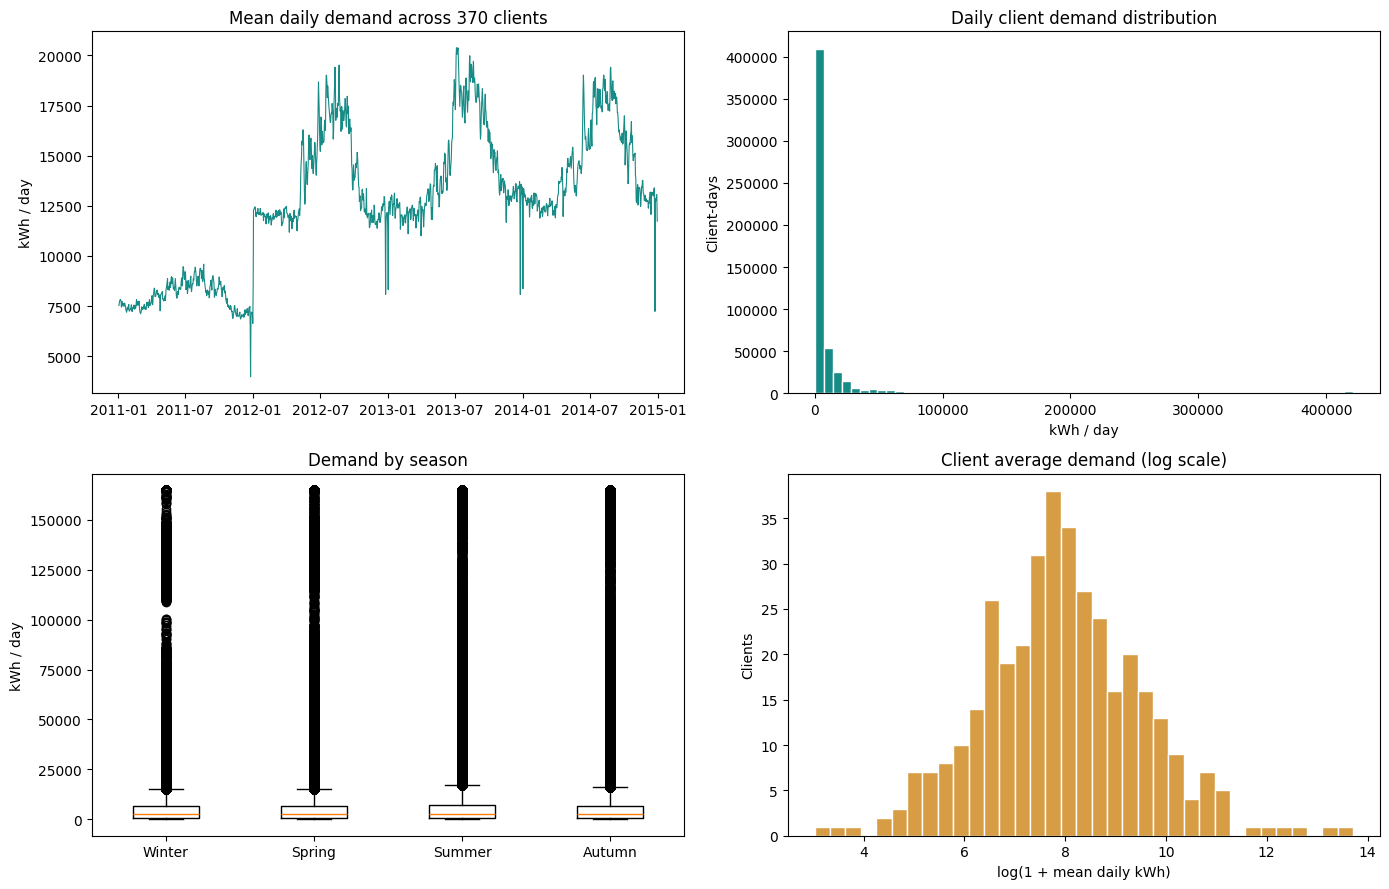

,count,mean,median,std
season,,,,
Winter,133200,11098.650391,2511.879883,49050.62
Spring,136160,11680.040039,2409.959961,56638.24
Summer,136160,14960.730469,2668.209961,90508.63
Autumn,134680,12990.179688,2565.639893,70070.42


,mean,median,std,max
client_id,,,,
MT_133,19.650000,0.0,42.16,223.759995
MT_160,27.860001,0.0,60.61,498.829987
MT_347,44.310001,0.0,66.85,370.029999
MT_003,70.089996,41.7,194.05,1881.189941
MT_117,86.879997,0.0,175.99,791.450012


,mean,median,std,max
client_id,,,,
MT_208,159928.75000,153925.42,23669.75,2.372017e+05
MT_370,209478.68750,33560.81,218423.30,5.843784e+05
MT_279,288957.53125,287146.66,32863.44,3.713227e+05
MT_196,498002.09375,482364.58,79400.70,7.431249e+05
MT_362,903205.18750,871325.00,653477.72,2.608175e+06


In [5]:
client_summary = daily.groupby("client_id").energy_kwh.agg(["mean", "median", "std", "max"]).sort_values("mean")
season_summary = daily.groupby("season").energy_kwh.agg(["count", "mean", "median", "std"]).reindex(SEASONS)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(daily_wide.index, daily_wide.mean(axis=1), color="#178b86", linewidth=.8)
axes[0, 0].set(title="Mean daily demand across 370 clients", ylabel="kWh / day")
axes[0, 1].hist(daily.energy_kwh.clip(upper=daily.energy_kwh.quantile(.995)), bins=60, color="#178b86", edgecolor="white")
axes[0, 1].set(title="Daily client demand distribution", xlabel="kWh / day", ylabel="Client-days")
axes[1, 0].boxplot([daily.loc[daily.season == s, "energy_kwh"].clip(upper=daily.energy_kwh.quantile(.99)) for s in SEASONS], tick_labels=SEASONS)
axes[1, 0].set(title="Demand by season", ylabel="kWh / day")
axes[1, 1].hist(np.log1p(client_summary["mean"]), bins=35, color="#d69d45", edgecolor="white")
axes[1, 1].set(title="Client average demand (log scale)", xlabel="log(1 + mean daily kWh)", ylabel="Clients")
plt.tight_layout()
plt.show()
display(season_summary.round(2))
display(client_summary.head(5).round(2))
display(client_summary.tail(5).round(2))

## 6. Build causal history features and the 30-day target

For each client and forecast origin date t:

- previous_30_day_kwh: total energy from the preceding 30 days
- previous_7_day_mean_kwh: average daily energy from the preceding 7 days
- previous_day_kwh: energy on day t−1
- previous_90_day_mean_kwh: a client-level baseline from the preceding 90 days
- month_sin, month_cos, and one-hot season: calendar features
- next_30_day_kwh: target energy from t through t+29

All history features end before t. We use one origin every seven days. This reduces nearly identical overlapping windows while keeping a large multi-client sample.

In [6]:
previous_30 = daily_wide.rolling(30, min_periods=30).sum().shift(1)
previous_7 = daily_wide.rolling(7, min_periods=7).mean().shift(1)
previous_day = daily_wide.shift(1)
previous_90 = daily_wide.rolling(90, min_periods=90).mean().shift(1)
future_30 = daily_wide.rolling(30, min_periods=30).sum().shift(-(HORIZON - 1))

origin_indices = np.arange(90, len(dates) - HORIZON, ORIGIN_SPACING)
origin_dates = dates[origin_indices]
records = []
for index in origin_indices:
    origin = pd.DataFrame({
        "forecast_date": dates[index],
        "forecast_end": dates[index] + pd.Timedelta(days=HORIZON - 1),
        "client_id": client_ids,
        "previous_30_day_kwh": previous_30.iloc[index].to_numpy(),
        "previous_7_day_mean_kwh": previous_7.iloc[index].to_numpy(),
        "previous_day_kwh": previous_day.iloc[index].to_numpy(),
        "previous_90_day_mean_kwh": previous_90.iloc[index].to_numpy(),
        "next_30_day_kwh": future_30.iloc[index].to_numpy(),
    })
    records.append(origin)
records = pd.concat(records, ignore_index=True)
records["month"] = records.forecast_date.dt.month
records["month_sin"] = np.sin(2 * np.pi * records.month / 12)
records["month_cos"] = np.cos(2 * np.pi * records.month / 12)
records["season"] = records.month.map(season_from_month)
records.to_csv(PROCESSED / "forecast_records.csv", index=False)

input_features = [
    "previous_30_day_kwh", "previous_7_day_mean_kwh", "previous_day_kwh",
    "previous_90_day_mean_kwh",
]
numeric_features = input_features + ["month_sin", "month_cos"]
feature_columns = numeric_features + ["season"]
X = records[feature_columns]
y = records.next_30_day_kwh
assert records.next_30_day_kwh.notna().all()
assert records.forecast_date.nunique() == len(origin_dates)
print(f"{len(records):,} labelled examples ({len(origin_dates)} weekly origins × {len(client_ids)} clients)")
display(records.head())

71,040 labelled examples (192 weekly origins × 370 clients)


,forecast_date,forecast_end,client_id,previous_30_day_kwh,previous_7_day_mean_kwh,previous_day_kwh,previous_90_day_mean_kwh,next_30_day_kwh,month,month_sin,month_cos,season
0,2011-04-02,2011-05-01,MT_001,0.0,0.0,0.0,0.0,0.0,4,0.866025,-0.5,Spring
1,2011-04-02,2011-05-01,MT_002,0.0,0.0,0.0,0.0,0.0,4,0.866025,-0.5,Spring
2,2011-04-02,2011-05-01,MT_003,0.0,0.0,0.0,0.0,0.0,4,0.866025,-0.5,Spring
3,2011-04-02,2011-05-01,MT_004,0.0,0.0,0.0,0.0,0.0,4,0.866025,-0.5,Spring
4,2011-04-02,2011-05-01,MT_005,0.0,0.0,0.0,0.0,0.0,4,0.866025,-0.5,Spring


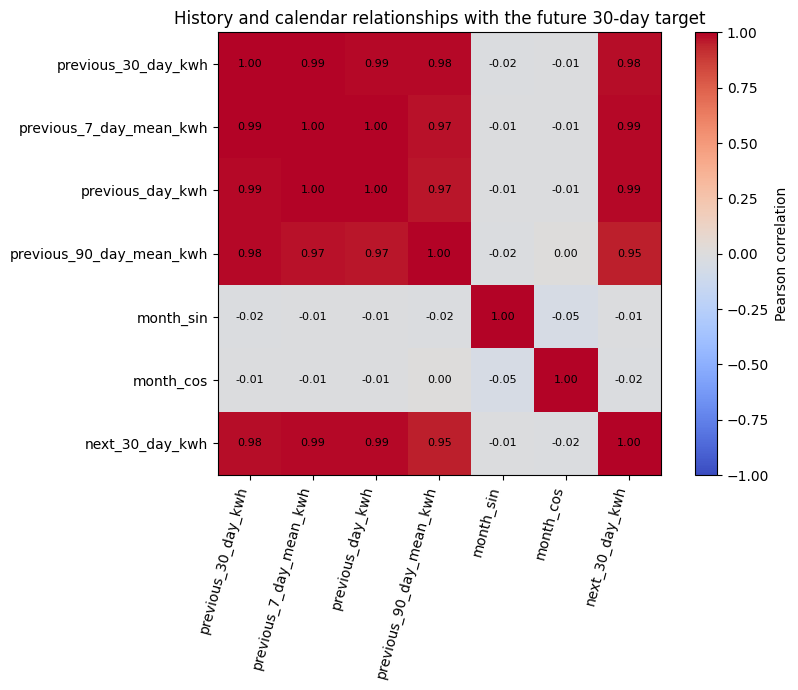

In [7]:
correlations = records[numeric_features + ["next_30_day_kwh"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlations)), correlations.columns, rotation=75, ha="right")
ax.set_yticks(range(len(correlations)), correlations.columns)
for row in range(len(correlations)):
    for column in range(len(correlations)):
        ax.text(column, row, f"{correlations.iloc[row, column]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("History and calendar relationships with the future 30-day target")
plt.tight_layout()
plt.show()

## 7. Chronological train/test design

The latest 20% of weekly forecast origins form the final holdout. Training origins whose 30-day target reaches the holdout are removed.

For cross-validation, we split origin dates, not arbitrary rows. A five-origin gap is at least 35 calendar days, so training target windows end before validation begins. Every client contributes rows at each origin, but no future dates enter the historical features.

In [8]:
test_start = origin_dates[int(len(origin_dates) * .8)]
train_origin_dates = origin_dates[origin_dates < test_start - pd.Timedelta(days=HORIZON - 1)]
test_origin_dates = origin_dates[origin_dates >= test_start]
train_mask = records.forecast_date.isin(train_origin_dates)
test_mask = records.forecast_date.isin(test_origin_dates)
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]
train_records, test_records = records.loc[train_mask], records.loc[test_mask]
assert train_records.forecast_end.max() < test_records.forecast_date.min()
cv = TimeSeriesSplit(n_splits=5, gap=5)
cv_dates = train_origin_dates
fold_dates = []
for fold, (training, validation) in enumerate(cv.split(cv_dates), 1):
    last_target = cv_dates[training].max() + pd.Timedelta(days=HORIZON - 1)
    first_validation = cv_dates[validation].min()
    assert last_target < first_validation
    fold_dates.append({
        "Fold": fold, "Training origins": len(training), "Validation origins": len(validation),
        "Last training target end": last_target.date(), "Validation starts": first_validation.date(),
    })
display(pd.DataFrame(fold_dates))
print("Holdout starts:", test_start.date(), "| Training rows:", len(X_train), "| Holdout rows:", len(X_test))

,Fold,Training origins,Validation origins,Last training target end,Validation starts
0,1,24,24,2011-10-09,2011-10-22
1,2,48,24,2012-03-25,2012-04-07
2,3,72,24,2012-09-09,2012-09-22
3,4,96,24,2013-02-24,2013-03-09
4,5,120,24,2013-08-11,2013-08-24


Holdout starts: 2014-03-08 | Training rows: 55130 | Holdout rows: 14430


## 8. Required models and preprocessing

We compare the five algorithms specified in the case study. Numeric values are median-imputed and standardised; season is one-hot encoded inside every training fold.

Client ID is deliberately not a predictor. The model learns from each client's past measured demand, which makes it possible to evaluate clients excluded from training.

In [9]:
def make_preprocessing(polynomial=False):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    if polynomial:
        numeric_steps.append(("polynomial", PolynomialFeatures(degree=2, include_bias=False)))
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("season", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), ["season"]),
    ])

estimators = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=SEED),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=8, n_jobs=-1, random_state=SEED),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=150, learning_rate=.05, max_depth=2, min_samples_leaf=10, random_state=SEED),
}
models = {
    name: Pipeline([
        ("preprocessing", make_preprocessing(name == "Polynomial Regression")),
        ("regressor", estimator),
    ])
    for name, estimator in estimators.items()
}
def regression_metrics(actual, predicted):
    mse = float(mean_squared_error(actual, predicted))
    return {
        "R2": float(r2_score(actual, predicted)),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(mean_absolute_error(actual, predicted)),
    }

In [10]:
fold_results = []
for name, pipeline in models.items():
    for fold, (training, validation) in enumerate(cv.split(cv_dates), 1):
        training_dates = cv_dates[training]
        validation_dates = cv_dates[validation]
        train_rows = records.forecast_date.isin(training_dates)
        validation_rows = records.forecast_date.isin(validation_dates)
        fitted = clone(pipeline).fit(X.loc[train_rows], y.loc[train_rows])
        predicted = fitted.predict(X.loc[validation_rows])
        fold_results.append({
            "Model": name, "Fold": fold,
            **regression_metrics(y.loc[validation_rows], predicted),
        })
    print("Completed chronological CV:", name)
fold_metrics = pd.DataFrame(fold_results)
cv_summary = fold_metrics.groupby("Model").agg(
    CV_RMSE=("RMSE", "mean"), CV_RMSE_std=("RMSE", "std"),
    CV_MAE=("MAE", "mean"), CV_MSE=("MSE", "mean"), CV_R2=("R2", "mean"),
)
selected_model = cv_summary.CV_RMSE.idxmin()
print("Selected using training-only CV:", selected_model)
display(cv_summary.sort_values("CV_RMSE").round(3))
fold_metrics.to_csv(ARTIFACTS / "cv_fold_metrics.csv", index=False)

Completed chronological CV: Linear Regression


Completed chronological CV: Polynomial Regression


Completed chronological CV: Decision Tree Regressor


Completed chronological CV: Random Forest Regressor


Completed chronological CV: Gradient Boosting Regressor
Selected using training-only CV: Linear Regression


,CV_RMSE,CV_RMSE_std,CV_MAE,CV_MSE,CV_R2
Model,,,,,
Linear Regression,345382.478,81085.620,40088.417,1.245490e+11,0.964
Gradient Boosting Regressor,654293.092,536401.854,57342.437,6.582810e+11,0.870
Random Forest Regressor,714118.393,543951.326,57327.919,7.466715e+11,0.850
Decision Tree Regressor,719871.218,499199.777,81798.502,7.175749e+11,0.852
Polynomial Regression,1295913.590,1429703.128,87830.959,3.314633e+12,-0.500


In [11]:
fitted_models = {}
holdout_predictions = {}
all_model_metrics = {}
for name, pipeline in models.items():
    fitted_models[name] = clone(pipeline).fit(X_train, y_train)
    holdout_predictions[name] = fitted_models[name].predict(X_test)
    all_model_metrics[name] = {
        **regression_metrics(y_test, holdout_predictions[name]),
        **{key: float(value) for key, value in cv_summary.loc[name].items()},
    }
comparison = pd.DataFrame.from_dict(all_model_metrics, orient="index").sort_values("CV_RMSE")
display(comparison.round(3))
best_model = fitted_models[selected_model]
best_predictions = holdout_predictions[selected_model]
test_metrics = regression_metrics(y_test, best_predictions)
holdout_winner = comparison.RMSE.idxmin()

,R2,MSE,RMSE,MAE,CV_RMSE,CV_RMSE_std,CV_MAE,CV_MSE,CV_R2
Linear Regression,0.986,7.802625e+10,279331.800,33297.543,345382.478,81085.620,40088.417,1.245490e+11,0.964
Gradient Boosting Regressor,0.995,3.044927e+10,174497.181,26869.056,654293.092,536401.854,57342.437,6.582810e+11,0.870
Random Forest Regressor,0.992,4.636255e+10,215319.654,25657.953,714118.393,543951.326,57327.919,7.466715e+11,0.850
Decision Tree Regressor,0.987,7.192442e+10,268187.291,57886.772,719871.218,499199.777,81798.502,7.175749e+11,0.852
Polynomial Regression,0.993,3.858419e+10,196428.582,31230.646,1295913.590,1429703.128,87830.959,3.314633e+12,-0.500


## 9. Persistence baseline and client holdout

The persistence baseline repeats the previous 30-day total. It is scored on exactly the same holdout examples.

Because the source has 370 clients, we also hold out a deterministic 20% of client IDs from model training and evaluate the CV-selected model on their later-period forecasts. These clients still provide their own prior history as input, but their future targets are never seen during fitting.

,R2,MSE,RMSE,MAE
Persistence (previous 30 days),0.968,1.803801e+11,424711.841,40892.006
Linear Regression,0.986,7.802625e+10,279331.800,33297.543


,R2,MSE,RMSE,MAE
Clients excluded from training,0.995,1.235973e+10,111174.338,26890.746


Comparable baseline rows: 14430
Unseen-client evaluation: 74 clients / 2886 forecast rows


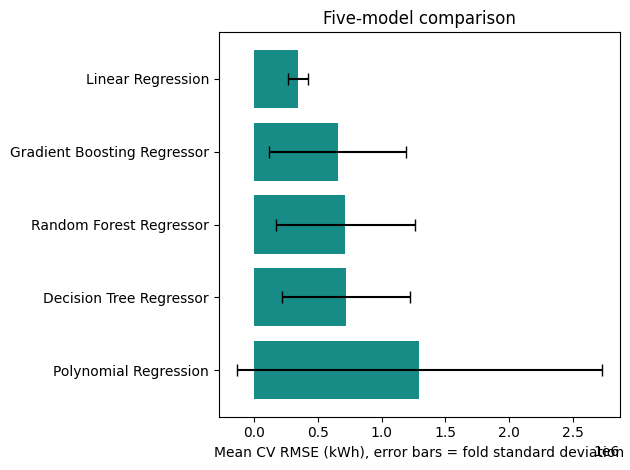

In [12]:
baseline_mask = X_test.previous_30_day_kwh.notna().to_numpy()
baseline_metrics = regression_metrics(y_test.iloc[baseline_mask], X_test.previous_30_day_kwh.iloc[baseline_mask])
model_on_baseline_rows = regression_metrics(y_test.iloc[baseline_mask], best_predictions[baseline_mask])
beats_baseline = model_on_baseline_rows["RMSE"] < baseline_metrics["RMSE"]

heldout_clients = set(client_ids[::5])
client_train_mask = train_mask & ~records.client_id.isin(heldout_clients)
client_test_mask = test_mask & records.client_id.isin(heldout_clients)
client_holdout_model = clone(models[selected_model]).fit(X.loc[client_train_mask], y.loc[client_train_mask])
client_holdout_prediction = client_holdout_model.predict(X.loc[client_test_mask])
unseen_client_metrics = regression_metrics(y.loc[client_test_mask], client_holdout_prediction)

display(pd.DataFrame({
    "Persistence (previous 30 days)": baseline_metrics,
    selected_model: model_on_baseline_rows,
}).T.round(3))
display(pd.DataFrame([unseen_client_metrics], index=["Clients excluded from training"]).round(3))
print("Comparable baseline rows:", int(baseline_mask.sum()))
print("Unseen-client evaluation:", len(heldout_clients), "clients /", int(client_test_mask.sum()), "forecast rows")
fig, ax = plt.subplots()
ordered = comparison.sort_values("CV_RMSE")
ax.barh(ordered.index, ordered.CV_RMSE, xerr=ordered.CV_RMSE_std, color="#178b86", capsize=4)
ax.invert_yaxis()
ax.set(xlabel="Mean CV RMSE (kWh), error bars = fold standard deviation", title="Five-model comparison")
plt.tight_layout()
plt.show()

## 10. Residual analysis of the CV-selected model

Residual = actual − predicted. We inspect calibration, error spread, time dependence, and seasonal performance. The final holdout contains later dates for all clients; successive 30-day targets still overlap because the forecast horizon is longer than the weekly origin spacing.

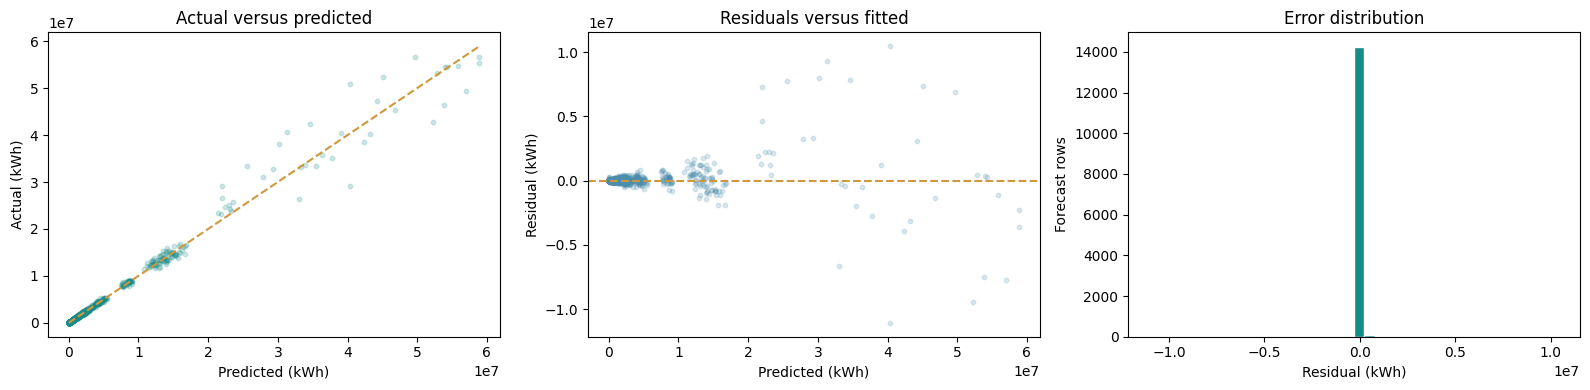

,count,mean,std
predicted,,,
"(-10342.961, 40309.558]",2886,-2401.89,12619.11
"(40309.558, 74511.432]",2886,-6315.75,10857.52
"(74511.432, 124578.604]",2886,-6681.78,13599.13
"(124578.604, 327832.848]",2886,-4735.34,17043.82
"(327832.848, 58934011.916]",2886,23245.88,623586.90


Residual standard-deviation ratio across prediction bands: 57.43
Lag-one residual correlation: 0.019


In [13]:
test_predictions = test_records[[
    "forecast_date", "forecast_end", "client_id", "season", "previous_30_day_kwh",
]].copy()
test_predictions["actual"] = y_test.to_numpy()
test_predictions["predicted"] = best_predictions
test_predictions["residual"] = test_predictions.actual - test_predictions.predicted
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(best_predictions, y_test, alpha=.2, s=10, color="#178b86")
bounds = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
axes[0].plot(bounds, bounds, "--", color="#cf983f")
axes[0].set(xlabel="Predicted (kWh)", ylabel="Actual (kWh)", title="Actual versus predicted")
axes[1].scatter(best_predictions, test_predictions.residual, alpha=.2, s=10, color="#4b8dac")
axes[1].axhline(0, linestyle="--", color="#cf983f")
axes[1].set(xlabel="Predicted (kWh)", ylabel="Residual (kWh)", title="Residuals versus fitted")
axes[2].hist(test_predictions.residual, bins=40, color="#178b86", edgecolor="white")
axes[2].set(xlabel="Residual (kWh)", ylabel="Forecast rows", title="Error distribution")
plt.tight_layout()
plt.show()

bands = pd.qcut(test_predictions.predicted, 5, duplicates="drop")
spread = test_predictions.groupby(bands, observed=True).residual.agg(["count", "mean", "std"])
spread_ratio = float(spread["std"].max() / spread["std"].min())
residual_correlation = float(test_predictions.residual.autocorr())
display(spread.round(2))
print(f"Residual standard-deviation ratio across prediction bands: {spread_ratio:.2f}")
print(f"Lag-one residual correlation: {residual_correlation:.3f}")

,Forecast rows,Actual mean,Predicted mean,RMSE,MAE
Season,,,,,
Winter,NaN,NaN,NaN,NaN,NaN
Spring,4810.0,418057.73,411071.41,270147.52,36288.57
Summer,4810.0,523155.62,521640.91,287357.29,33928.49
Autumn,4810.0,430226.48,436860.84,280222.89,29675.57


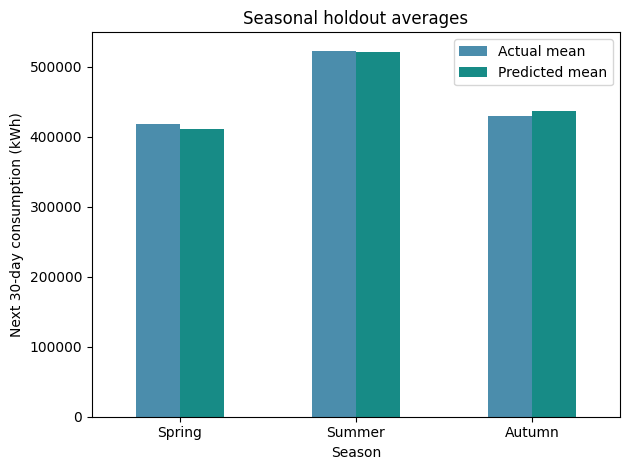

,feature,rmse_increase,std
1,previous_7_day_mean_kwh,1910087.955,4752.131
2,previous_day_kwh,1516540.094,4236.276
3,previous_90_day_mean_kwh,277956.187,577.425
0,previous_30_day_kwh,21235.597,489.388
4,month_sin,643.497,25.960
6,season,194.781,78.893
5,month_cos,-26.542,19.984


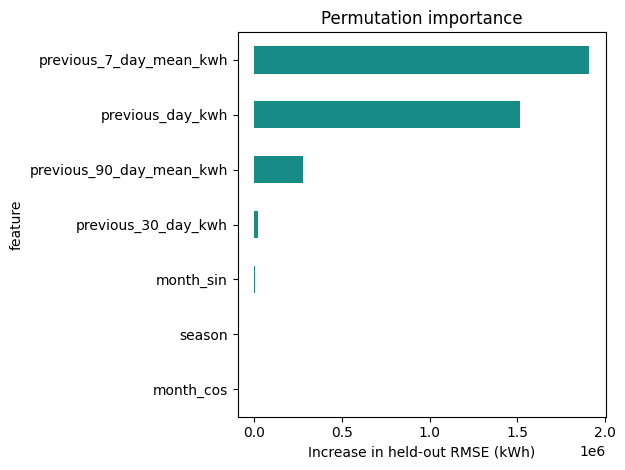

In [14]:
season_rows = []
for season, group in test_predictions.groupby("season"):
    season_rows.append({
        "Season": season, "Forecast rows": len(group),
        "Actual mean": group.actual.mean(), "Predicted mean": group.predicted.mean(),
        "RMSE": np.sqrt(mean_squared_error(group.actual, group.predicted)),
        "MAE": mean_absolute_error(group.actual, group.predicted),
    })
season_performance = pd.DataFrame(season_rows).set_index("Season").reindex(SEASONS)
display(season_performance.round(2))
season_performance[["Actual mean", "Predicted mean"]].dropna().plot.bar(color=["#4b8dac", "#178b86"])
plt.ylabel("Next 30-day consumption (kWh)")
plt.title("Seasonal holdout averages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

permuted = permutation_importance(
    best_model, X_test, y_test,
    scoring="neg_root_mean_squared_error", n_repeats=3, random_state=SEED, n_jobs=-1,
)
importance = pd.DataFrame({
    "feature": feature_columns,
    "rmse_increase": permuted.importances_mean,
    "std": permuted.importances_std,
}).sort_values("rmse_increase", ascending=False)
display(importance.round(3))
importance.sort_values("rmse_increase").plot.barh(x="feature", y="rmse_increase", legend=False, color="#178b86")
plt.xlabel("Increase in held-out RMSE (kWh)")
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

## 11. Refit and export the deployment artifacts

After selecting the model with training-only chronological CV, refit it on all labelled client-date examples. Saved holdout predictions remain from the model fit without holdout rows.

App presets are actual measured-history rows. The app accepts a client example, four prior-history values, and a forecast date. Client ID is displayed for context but is not used as a model feature.

In [15]:
deployment_model = clone(models[selected_model]).fit(X, y)
joblib.dump(deployment_model, ARTIFACTS / "best_model.joblib")
test_predictions.to_csv(ARTIFACTS / "test_predictions.csv", index=False)
importance.to_csv(ARTIFACTS / "feature_importance.csv", index=False)

bounds = {
    column: {
        "min": float(X[column].min()),
        "max": float(X[column].max()),
        "median": float(X[column].median()),
    }
    for column in input_features
}
presets = []
for name, quantile in [
    ("Typical measured client", .50),
    ("Lower-demand measured client", .20),
    ("Higher-demand measured client", .80),
]:
    target_value = records.previous_30_day_kwh.quantile(quantile)
    row = records.loc[(records.previous_30_day_kwh - target_value).abs().idxmin()]
    presets.append({
        "name": name,
        "client_id": row.client_id,
        "forecast_date": row.forecast_date.strftime("%Y-%m-%d"),
        "inputs": {column: float(row[column]) for column in input_features},
    })

config = {
    "dataset_type": "real_multi_client_15_minute_readings",
    "clients": len(client_ids),
    "client_ids": client_ids,
    "interval_minutes": 15,
    "horizon_days": HORIZON,
    "origin_spacing_days": ORIGIN_SPACING,
    "feature_columns": feature_columns,
    "input_features": input_features,
    "numeric_features": numeric_features,
    "categorical_features": ["season"],
    "target_column": "next_30_day_kwh",
    "target_unit": "kWh",
    "season_options": SEASONS,
    "bounds": bounds,
    "presets": presets,
}
metrics = {
    "selected_model": selected_model,
    "selection_metric": "CV_RMSE",
    "cross_validation": "5-fold expanding TimeSeriesSplit on weekly origins, 5-origin (35-day) gap",
    "horizon_days": HORIZON,
    "origin_spacing_days": ORIGIN_SPACING,
    "clients": len(client_ids),
    "rows": len(records),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "train_origins": len(train_origin_dates),
    "test_origins": len(test_origin_dates),
    "test_date_range": [
        test_records.forecast_date.min().strftime("%Y-%m-%d"),
        test_records.forecast_date.max().strftime("%Y-%m-%d"),
    ],
    "last_training_target_end": train_records.forecast_end.max().strftime("%Y-%m-%d"),
    "test_metrics": test_metrics,
    "holdout_winner": holdout_winner,
    "all_model_metrics": all_model_metrics,
    "baseline_metrics": baseline_metrics,
    "model_on_baseline_rows": model_on_baseline_rows,
    "baseline_comparable_rows": int(baseline_mask.sum()),
    "beats_persistence_baseline": bool(beats_baseline),
    "heldout_client_count": len(heldout_clients),
    "heldout_client_rows": int(client_test_mask.sum()),
    "heldout_client_metrics": unseen_client_metrics,
    "residual_std_ratio": spread_ratio,
    "residual_lag1_correlation": residual_correlation,
    "sklearn_version": sklearn.__version__,
}
metadata = {
    **manifest,
    "synthetic": False,
    "raw_rows": len(raw),
    "clients": len(client_ids),
    "interval_minutes": 15,
    "daily_rows": len(daily),
    "daily_dates": len(dates),
    "forecast_examples": len(records),
    "weekly_origins": len(origin_dates),
    "horizon_days": HORIZON,
    "missing_intervals": int(raw[client_ids].isna().sum().sum()),
    "date_range": [str(timestamps.min()), str(timestamps.max())],
}
for path, payload in [
    (ARTIFACTS / "metrics.json", metrics),
    (ARTIFACTS / "feature_config.json", config),
    (PROCESSED / "dataset_metadata.json", metadata),
]:
    path.write_text(json.dumps(payload, indent=2, allow_nan=False) + "\n")
print("Saved multi-client artifacts. Deployment model refitted on", len(records), "examples.")

Saved multi-client artifacts. Deployment model refitted on 71040 examples.


## 12. Answer the case-study questions from the measured results

The conclusions below are calculated from the executed experiment. The cross-validation winner and final holdout winner are reported separately so the holdout is not used to select the deployed model.

In [16]:
top_feature = importance.iloc[0].feature
baseline_statement = (
    "The selected model beats the persistence baseline on comparable holdout rows."
    if beats_baseline else
    "The persistence baseline is better on comparable holdout rows."
)
display(Markdown(f'''
1. **Can client consumption be predicted?** The selected model is **{selected_model}**, with holdout RMSE **{test_metrics["RMSE"]:.2f} kWh**, MAE **{test_metrics["MAE"]:.2f} kWh**, and R² **{test_metrics["R2"]:.3f}** for the next 30 days. {baseline_statement}
2. **Which factor has the greatest effect?** The largest permutation RMSE increase is **{top_feature}**. This measures predictive reliance, not causation.
3. **Is seasonal variation captured?** Month sine/cosine and one-hot season allow calendar variation to be learned. Seasonal holdout means and errors are shown above.
4. **Does the residual plot show constant variance?** Residual standard deviations differ by **{spread_ratio:.2f}×** across prediction bands. Constant variance is not established; the residual plot should be inspected.
5. **Which algorithm achieves the lowest RMSE?** **{selected_model}** has the lowest mean training CV RMSE (**{comparison.loc[selected_model, "CV_RMSE"]:.2f} kWh**). **{holdout_winner}** has the lowest final holdout RMSE (**{comparison.loc[holdout_winner, "RMSE"]:.2f} kWh**).
6. **How does it perform on new clients?** On {len(heldout_clients)} clients excluded from fitting, the selected model's RMSE is **{unseen_client_metrics["RMSE"]:.2f} kWh** over {int(client_test_mask.sum())} later-period rows. These clients still provide prior history, but no target rows are used for training.
7. **Can it be deployed for demand forecasting?** The Streamlit app forecasts next-30-day energy from actual history examples. Utility deployment still needs weather, current data, calibrated intervals, peak-load targets, and prospective validation.
'''))


1. **Can client consumption be predicted?** The selected model is **Linear Regression**, with holdout RMSE **279331.80 kWh**, MAE **33297.54 kWh**, and R² **0.986** for the next 30 days. The selected model beats the persistence baseline on comparable holdout rows.
2. **Which factor has the greatest effect?** The largest permutation RMSE increase is **previous_7_day_mean_kwh**. This measures predictive reliance, not causation.
3. **Is seasonal variation captured?** Month sine/cosine and one-hot season allow calendar variation to be learned. Seasonal holdout means and errors are shown above.
4. **Does the residual plot show constant variance?** Residual standard deviations differ by **57.43×** across prediction bands. Constant variance is not established; the residual plot should be inspected.
5. **Which algorithm achieves the lowest RMSE?** **Linear Regression** has the lowest mean training CV RMSE (**345382.48 kWh**). **Gradient Boosting Regressor** has the lowest final holdout RMSE (**174497.18 kWh**).
6. **How does it perform on new clients?** On 74 clients excluded from fitting, the selected model's RMSE is **111174.34 kWh** over 2886 later-period rows. These clients still provide prior history, but no target rows are used for training.
7. **Can it be deployed for demand forecasting?** The Streamlit app forecasts next-30-day energy from actual history examples. Utility deployment still needs weather, current data, calibrated intervals, peak-load targets, and prospective validation.


## 13. Limitations and real-world applicability

- The UCI file has 370 client meters but does not provide household size, room count, appliance count, AC hours, weather, or occupancy. “Client” is the precise source term; not every client is proven to be a household.
- Source values are 15-minute kW readings. We convert them to kWh and aggregate daily. The published table has no missing cells, but zeros before a meter becomes active are part of the source convention.
- Weekly forecast origins still have overlapping 30-day targets. The chronological 35-day gaps prevent training targets from reaching validation origins, but validation errors remain correlated.
- Client-holdout evaluation tests a new client's later period when prior history is available. It does not test a brand-new client with no readings.
- A 30-day energy forecast does not estimate instantaneous peak load. Grid planning needs a separate peak-demand target.
- The ±RMSE range in the app is a planning indication, not a calibrated probability interval.
- Polynomial regression can become unstable when interactions and squared terms are numerous. Model selection is based on training-only chronological CV, not on whichever model happens to win the holdout.
- Results describe this source's clients and 2011–2014 behaviour. They should not be generalized to a utility population without recent validation.

**Reproduce:** install requirements.txt, run all notebook cells, run python validate_project.py, and launch streamlit run app.py. The notebook downloads the real UCI archive and records its hashes; no synthetic training data is used.